# 06 - Forecasting Models

**Purpose:** compare baselines and Random Forest models for two tasks:

- next-month review-count regression;
- attention-pulse classification.

The main comparison is whether SNA and NLP features add useful signal beyond time-series history and business metadata.

In [1]:
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "new_orleans"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures" / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

FORECASTING_DATASET_PATH = PROCESSED_DIR / "forecasting_dataset.csv"
COHORT_BUSINESSES_PATH = PROCESSED_DIR / "forecasting_cohort_businesses.csv"
METRICS_OUTPUT_PATH = OUTPUTS_DIR / "forecasting_metrics.csv"
PREDICTIONS_OUTPUT_PATH = OUTPUTS_DIR / "forecasting_predictions.csv"
PULSE_METRICS_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_metrics.csv"
PULSE_PREDICTIONS_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_predictions.csv"

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
modeling = pd.read_csv(FORECASTING_DATASET_PATH)
business_lookup = pd.read_csv(COHORT_BUSINESSES_PATH)[["business_id", "name", "categories"]]
print(modeling.shape)
modeling.head()

(68249, 58)


,business_id,monthly_review_count,monthly_star_sum,prev_month_reviews,rolling_3_avg,rolling_6_avg,same_month_previous_year,cumulative_review_count,cumulative_star_sum,avg_rating_history,...,feature_month_str,target_month_str,calendar_month,month_sin,month_cos,feature_month_number,pulse_baseline_reviews,pulse_relative_lift,attention_pulse,first_active_feature_month_str
0,-1XSzguS6XLN-V6MVZMg2A,6,29.0,6,2.000000,1.000000,0.0,6,29.0,4.833333,...,2015-12,2016-01,12,-2.449294e-16,1.000000e+00,12,1.000000,6.000000,1,2015-12
1,-1XSzguS6XLN-V6MVZMg2A,6,30.0,6,4.000000,2.000000,0.0,12,59.0,4.916667,...,2016-01,2016-02,1,5.000000e-01,8.660254e-01,13,2.000000,8.500000,1,2015-12
2,-1XSzguS6XLN-V6MVZMg2A,17,84.0,17,9.666667,4.833333,0.0,29,143.0,4.931034,...,2016-02,2016-03,2,8.660254e-01,5.000000e-01,14,4.833333,2.896552,1,2015-12
3,-1XSzguS6XLN-V6MVZMg2A,14,67.0,14,12.333333,7.166667,0.0,43,210.0,4.883721,...,2016-03,2016-04,3,1.000000e+00,6.123234e-17,15,7.166667,2.790698,1,2015-12
4,-1XSzguS6XLN-V6MVZMg2A,20,97.0,20,17.000000,10.500000,0.0,63,307.0,4.873016,...,2016-04,2016-05,4,8.660254e-01,-5.000000e-01,16,10.500000,1.142857,0,2015-12


In [2]:
def wape(y_true, y_pred):
    denominator = np.sum(np.abs(y_true))
    return np.nan if denominator == 0 else np.sum(np.abs(y_true - y_pred)) / denominator

def safe_auc(metric_fn, y_true, score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return metric_fn(y_true, score)

def evaluate_regression(split_name, model_name, y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return {
        "split": split_name,
        "task": "review_count_regression",
        "model": model_name,
        "rows": len(y_true),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "WAPE": wape(y_true, y_pred),
    }

def evaluate_classification(split_name, model_name, y_true, y_pred, y_score):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    return {
        "split": split_name,
        "task": "attention_pulse_classification",
        "model": model_name,
        "rows": len(y_true),
        "positive_rate": y_true.mean(),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": safe_auc(roc_auc_score, y_true, y_score),
        "PR_AUC": safe_auc(average_precision_score, y_true, y_score),
    }

splits = {
    "primary_covid_test": {"train_start": "2015-02", "train_end": "2019-12", "test_start": "2020-01", "test_end": "2021-12"},
    "secondary_pre_covid_test": {"train_start": "2015-02", "train_end": "2018-12", "test_start": "2019-01", "test_end": "2019-12"},
}

historical_features = ["prev_month_reviews", "rolling_3_avg", "rolling_6_avg", "same_month_previous_year", "cumulative_review_count", "avg_rating_history", "calendar_month", "month_sin", "month_cos", "feature_month_number"]
business_features = ["business_stars", "business_review_count", "is_restaurant", "is_food", "is_nightlife", "is_tourism"]
static_sna_features = [
    "recent_reviewer_count",
    "avg_reviewer_degree",
    "avg_reviewer_weighted_degree",
    "max_reviewer_pagerank",
    "max_reviewer_weighted_pagerank",
    "avg_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_degree",
    "avg_reviewer_friend_shared_businesses",
    "avg_reviewer_friend_category_overlap",
    "fraction_connected_reviewers",
    "fraction_weighted_connected_reviewers",
    "fraction_repeat_reviewers",
    "reviewer_community_diversity",
]
dynamic_social_exposure_features = [
    "fraction_active_to_date_reviewers",
    "avg_reviewer_reviews_to_date",
    "max_reviewer_reviews_to_date",
    "avg_reviewer_active_months_to_date",
    "fraction_largest_component_reviewers",
    "fraction_high_weighted_pagerank_reviewers",
    "fraction_high_weighted_degree_reviewers",
    "avg_reviewer_recency_months",
    "fraction_current_month_reviewers",
]
sna_features = static_sna_features + dynamic_social_exposure_features
nlp_features = [
    "recent_text_review_count",
    "avg_recent_review_char_count",
    "avg_recent_review_word_count",
    "share_recent_positive_language",
    "share_recent_negative_language",
    "avg_recent_positive_word_hits",
    "avg_recent_negative_word_hits",
    "recent_text_avg_stars",
]

feature_sets = {
    "ML: historical": historical_features,
    "ML: historical + business": historical_features + business_features,
    "ML: historical + SNA": historical_features + sna_features,
    "ML: historical + NLP": historical_features + nlp_features,
    "ML: all modalities": historical_features + business_features + sna_features + nlp_features,
}

required_columns = historical_features + business_features + sna_features + nlp_features + ["attention_pulse", "pulse_baseline_reviews", "pulse_relative_lift"]
missing_features = [feature for feature in required_columns if feature not in modeling.columns]
if missing_features:
    raise ValueError(f"Missing modeling features. Rerun notebook 05: {missing_features}")

In [3]:
regression_metrics = []
regression_prediction_frames = []
regression_models = {}

for split_name, split in splits.items():
    train_mask = (modeling["target_month_str"] >= split["train_start"]) & (modeling["target_month_str"] <= split["train_end"])
    test_mask = (modeling["target_month_str"] >= split["test_start"]) & (modeling["target_month_str"] <= split["test_end"])
    train_df = modeling[train_mask].copy()
    test_df = modeling[test_mask].copy()
    y_train = train_df["target_next_month_reviews"].astype(float)
    y_test = test_df["target_next_month_reviews"].astype(float)

    baseline_predictions = {
        "Baseline: last month": test_df["prev_month_reviews"].values,
        "Baseline: rolling 3-month avg": test_df["rolling_3_avg"].values,
        "Baseline: seasonal naive": test_df["same_month_previous_year"].values,
    }
    for model_name, y_pred in baseline_predictions.items():
        regression_metrics.append(evaluate_regression(split_name, model_name, y_test.values, y_pred))
        regression_prediction_frames.append(test_df[["business_id", "feature_month_str", "target_month_str", "target_next_month_reviews"]].assign(split=split_name, model=model_name, prediction=np.clip(y_pred, 0, None)))

    for model_name, features in feature_sets.items():
        model = RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1)
        model.fit(train_df[features], y_train)
        y_pred = model.predict(test_df[features])
        regression_metrics.append(evaluate_regression(split_name, model_name, y_test.values, y_pred))
        regression_prediction_frames.append(test_df[["business_id", "feature_month_str", "target_month_str", "target_next_month_reviews"]].assign(split=split_name, model=model_name, prediction=np.clip(y_pred, 0, None)))
        regression_models[(split_name, model_name)] = (model, features)

metrics_df = pd.DataFrame(regression_metrics).sort_values(["split", "WAPE", "MAE"])
predictions_df = pd.concat(regression_prediction_frames, ignore_index=True)
metrics_df.to_csv(METRICS_OUTPUT_PATH, index=False)
predictions_df.to_csv(PREDICTIONS_OUTPUT_PATH, index=False)
metrics_df

,split,task,model,rows,MAE,RMSE,WAPE
0,primary_covid_test,review_count_regression,Baseline: last month,21024,1.601170,3.007150,0.664292
1,primary_covid_test,review_count_regression,Baseline: rolling 3-month avg,21024,1.646071,3.364436,0.682921
3,primary_covid_test,review_count_regression,ML: historical,21024,1.791595,3.432584,0.743295
5,primary_covid_test,review_count_regression,ML: historical + SNA,21024,1.797421,3.397139,0.745712
6,primary_covid_test,review_count_regression,ML: historical + NLP,21024,1.798615,3.426518,0.746208
4,primary_covid_test,review_count_regression,ML: historical + business,21024,1.839525,3.513199,0.763181
7,primary_covid_test,review_count_regression,ML: all modalities,21024,1.871549,3.507464,0.776467
2,primary_covid_test,review_count_regression,Baseline: seasonal naive,21024,3.596128,7.490338,1.491959
12,secondary_pre_covid_test,review_count_regression,ML: historical + business,10511,2.230412,3.532347,0.369195
15,secondary_pre_covid_test,review_count_regression,ML: all modalities,10511,2.238087,3.538540,0.370465


In [4]:
pulse_metrics = []
pulse_prediction_frames = []
pulse_models = {}

for split_name, split in splits.items():
    train_mask = (modeling["target_month_str"] >= split["train_start"]) & (modeling["target_month_str"] <= split["train_end"])
    test_mask = (modeling["target_month_str"] >= split["test_start"]) & (modeling["target_month_str"] <= split["test_end"])
    train_df = modeling[train_mask].copy()
    test_df = modeling[test_mask].copy()
    y_train = train_df["attention_pulse"].astype(int)
    y_test = test_df["attention_pulse"].astype(int)

    baseline_scores = {
        "Baseline: previous-month pulse rule": (
            (test_df["prev_month_reviews"] >= 3)
            & (test_df["prev_month_reviews"] >= test_df["rolling_6_avg"] + 2)
            & (test_df["prev_month_reviews"] >= 1.5 * np.maximum(test_df["rolling_6_avg"], 1))
        ).astype(int),
        "Baseline: rising recent activity": (
            (test_df["rolling_3_avg"] > test_df["rolling_6_avg"])
            & (test_df["prev_month_reviews"] >= 3)
        ).astype(int),
    }
    for model_name, y_score in baseline_scores.items():
        y_pred = np.asarray(y_score, dtype=int)
        pulse_metrics.append(evaluate_classification(split_name, model_name, y_test.values, y_pred, y_pred))
        pulse_prediction_frames.append(test_df[["business_id", "feature_month_str", "target_month_str", "attention_pulse", "target_next_month_reviews", "pulse_baseline_reviews", "pulse_relative_lift"]].assign(split=split_name, model=model_name, prediction=y_pred, probability=y_pred))

    for model_name, features in feature_sets.items():
        model = RandomForestClassifier(
            n_estimators=140,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )
        model.fit(train_df[features], y_train)
        y_score = model.predict_proba(test_df[features])[:, 1]
        y_pred = (y_score >= 0.5).astype(int)
        pulse_metrics.append(evaluate_classification(split_name, model_name, y_test.values, y_pred, y_score))
        pulse_prediction_frames.append(test_df[["business_id", "feature_month_str", "target_month_str", "attention_pulse", "target_next_month_reviews", "pulse_baseline_reviews", "pulse_relative_lift"]].assign(split=split_name, model=model_name, prediction=y_pred, probability=y_score))
        pulse_models[(split_name, model_name)] = (model, features)

pulse_metrics_df = pd.DataFrame(pulse_metrics).sort_values(["split", "F1", "PR_AUC"], ascending=[True, False, False])
pulse_predictions_df = pd.concat(pulse_prediction_frames, ignore_index=True)
pulse_metrics_df.to_csv(PULSE_METRICS_OUTPUT_PATH, index=False)
pulse_predictions_df.to_csv(PULSE_PREDICTIONS_OUTPUT_PATH, index=False)
pulse_metrics_df

,split,task,model,rows,positive_rate,accuracy,precision,recall,F1,ROC_AUC,PR_AUC
1,primary_covid_test,attention_pulse_classification,Baseline: rising recent activity,21024,0.102407,0.799800,0.222162,0.381793,0.280882,0.614642,0.148129
0,primary_covid_test,attention_pulse_classification,Baseline: previous-month pulse rule,21024,0.102407,0.864488,0.286241,0.216442,0.246496,0.577433,0.142196
3,primary_covid_test,attention_pulse_classification,ML: historical + business,21024,0.102407,0.855927,0.218509,0.157919,0.183338,0.663415,0.175532
2,primary_covid_test,attention_pulse_classification,ML: historical,21024,0.102407,0.854880,0.203435,0.143056,0.167985,0.644538,0.161114
6,primary_covid_test,attention_pulse_classification,ML: all modalities,21024,0.102407,0.865202,0.224737,0.129122,0.164012,0.671053,0.176227
4,primary_covid_test,attention_pulse_classification,ML: historical + SNA,21024,0.102407,0.865535,0.202297,0.106363,0.139422,0.656962,0.164170
5,primary_covid_test,attention_pulse_classification,ML: historical + NLP,21024,0.102407,0.849886,0.166334,0.116117,0.136761,0.638302,0.150640
9,secondary_pre_covid_test,attention_pulse_classification,ML: historical,10511,0.131957,0.718961,0.223633,0.457102,0.300332,0.660902,0.244637
12,secondary_pre_covid_test,attention_pulse_classification,ML: historical + NLP,10511,0.131957,0.742841,0.230328,0.405191,0.293703,0.655591,0.232632
10,secondary_pre_covid_test,attention_pulse_classification,ML: historical + business,10511,0.131957,0.784797,0.254075,0.325883,0.285534,0.661108,0.245173


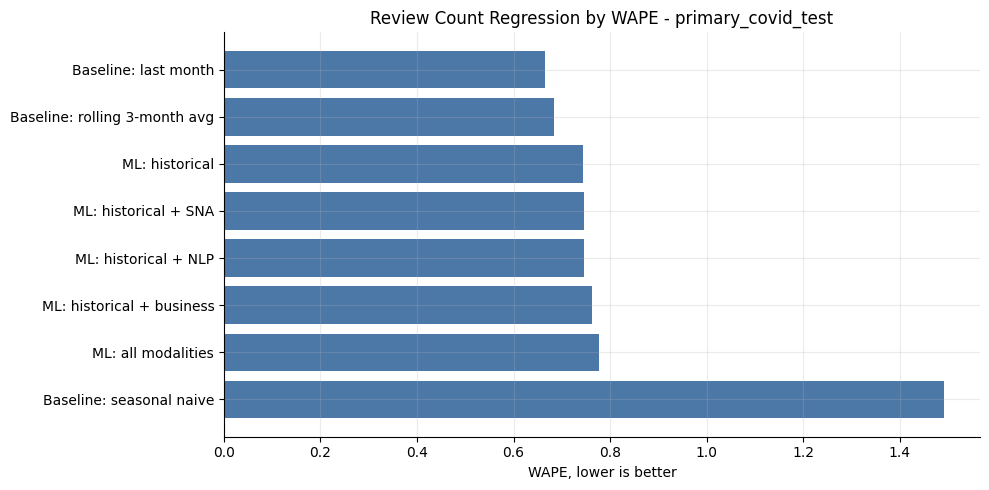

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_wape_comparison_primary_covid_test.png


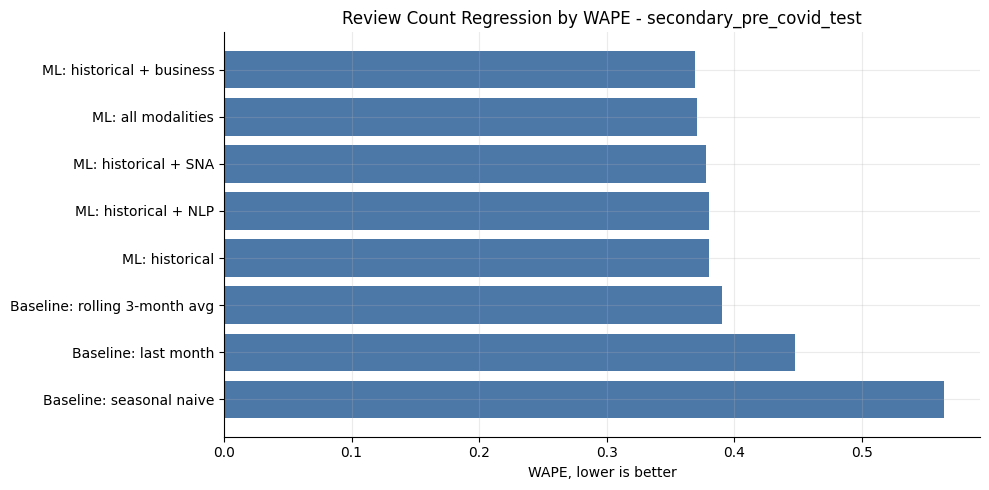

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_wape_comparison_secondary_pre_covid_test.png


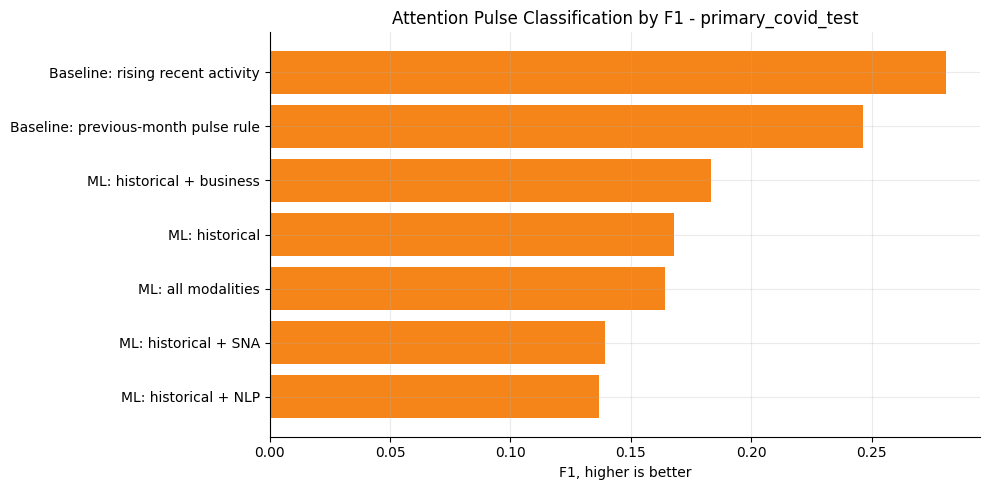

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_f1_comparison_primary_covid_test.png


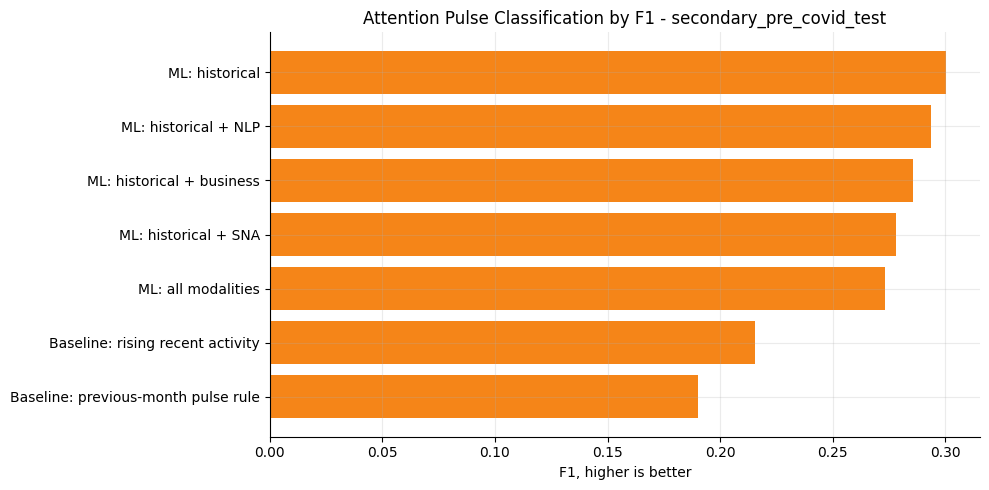

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_f1_comparison_secondary_pre_covid_test.png


In [5]:
for split_name in metrics_df["split"].unique():
    split_metrics = metrics_df[metrics_df["split"] == split_name].sort_values("WAPE")
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(split_metrics["model"], split_metrics["WAPE"], color="#4C78A8")
    ax.invert_yaxis()
    ax.set_title(f"Review Count Regression by WAPE - {split_name}")
    ax.set_xlabel("WAPE, lower is better")
    fig.tight_layout()
    path = FIGURES_DIR / f"review_count_wape_comparison_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

for split_name in pulse_metrics_df["split"].unique():
    split_metrics = pulse_metrics_df[pulse_metrics_df["split"] == split_name].sort_values("F1", ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(split_metrics["model"], split_metrics["F1"], color="#F58518")
    ax.invert_yaxis()
    ax.set_title(f"Attention Pulse Classification by F1 - {split_name}")
    ax.set_xlabel("F1, higher is better")
    fig.tight_layout()
    path = FIGURES_DIR / f"attention_pulse_f1_comparison_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

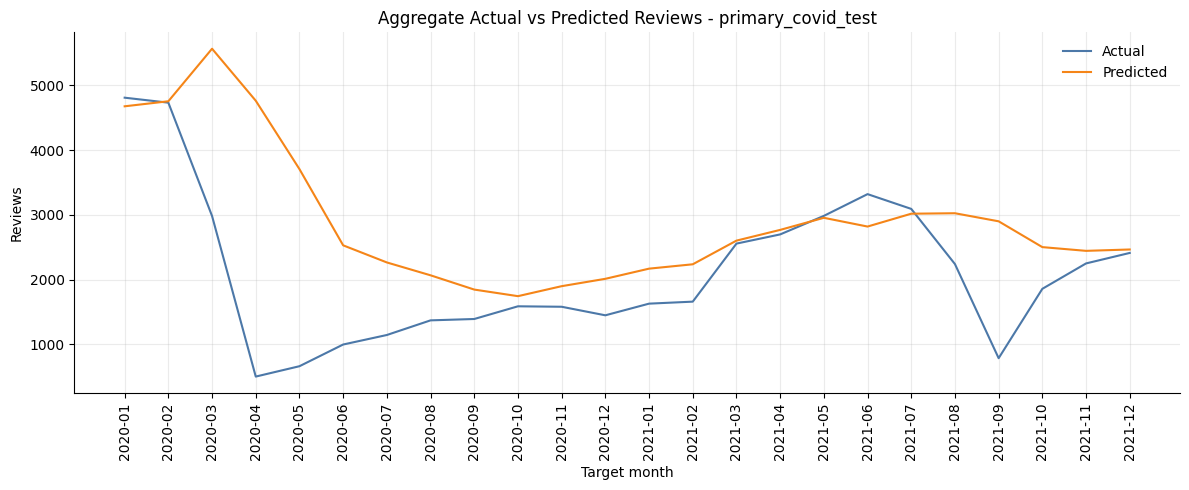

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_actual_vs_predicted_primary_covid_test.png


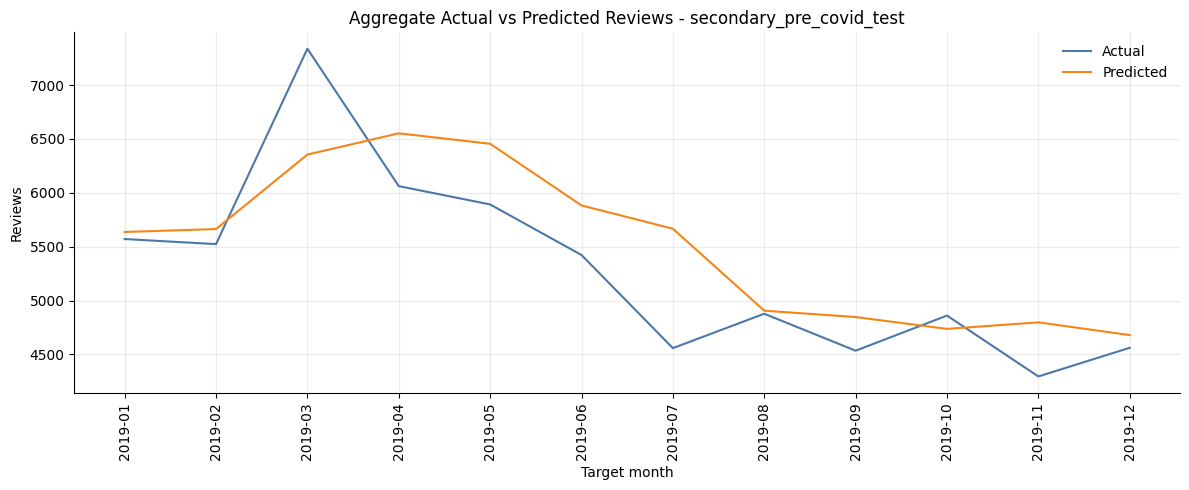

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_actual_vs_predicted_secondary_pre_covid_test.png


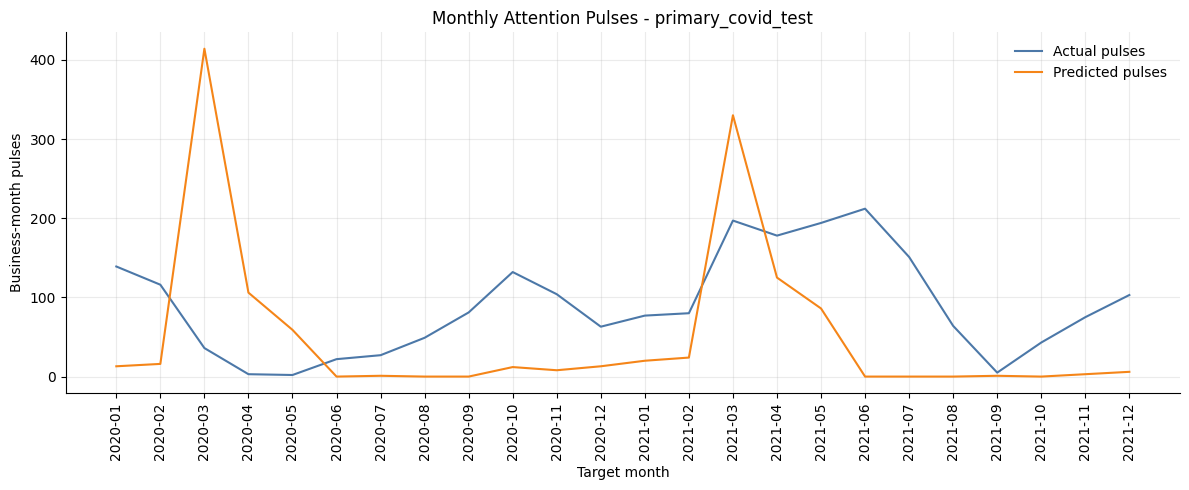

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_actual_vs_predicted_primary_covid_test.png


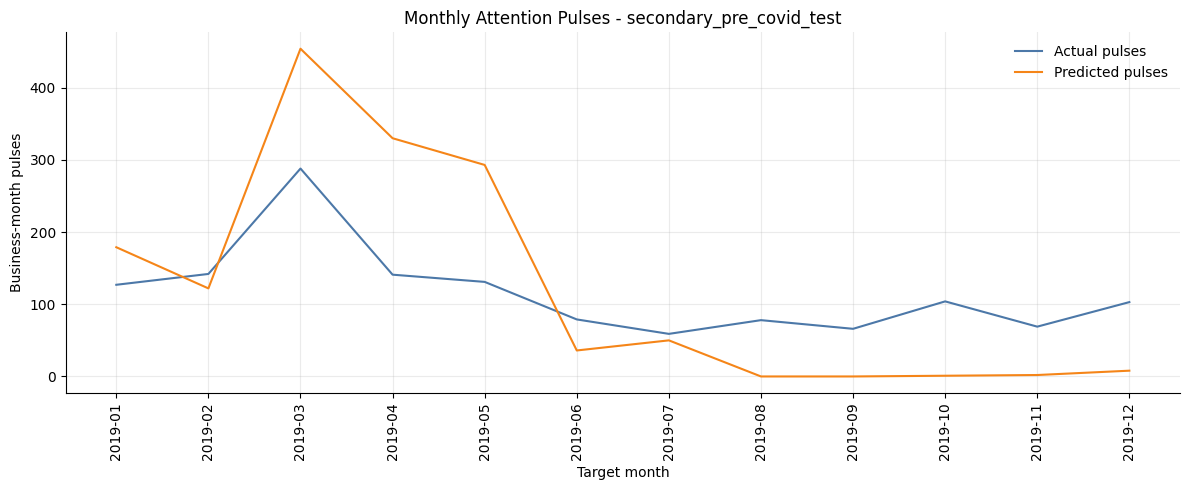

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_actual_vs_predicted_secondary_pre_covid_test.png


In [6]:
comparison_model = "ML: all modalities"
for split_name in predictions_df["split"].unique():
    plot_df = predictions_df[(predictions_df["split"] == split_name) & (predictions_df["model"] == comparison_model)].copy()
    monthly = plot_df.groupby("target_month_str").agg(actual=("target_next_month_reviews", "sum"), predicted=("prediction", "sum")).reset_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly["target_month_str"], monthly["actual"], label="Actual", color="#4C78A8")
    ax.plot(monthly["target_month_str"], monthly["predicted"], label="Predicted", color="#F58518")
    ax.set_title(f"Aggregate Actual vs Predicted Reviews - {split_name}")
    ax.set_xlabel("Target month")
    ax.set_ylabel("Reviews")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(frameon=False)
    fig.tight_layout()
    path = FIGURES_DIR / f"review_count_actual_vs_predicted_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

for split_name in pulse_predictions_df["split"].unique():
    plot_df = pulse_predictions_df[(pulse_predictions_df["split"] == split_name) & (pulse_predictions_df["model"] == comparison_model)].copy()
    monthly = plot_df.groupby("target_month_str").agg(actual_pulses=("attention_pulse", "sum"), predicted_pulses=("prediction", "sum")).reset_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly["target_month_str"], monthly["actual_pulses"], label="Actual pulses", color="#4C78A8")
    ax.plot(monthly["target_month_str"], monthly["predicted_pulses"], label="Predicted pulses", color="#F58518")
    ax.set_title(f"Monthly Attention Pulses - {split_name}")
    ax.set_xlabel("Target month")
    ax.set_ylabel("Business-month pulses")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(frameon=False)
    fig.tight_layout()
    path = FIGURES_DIR / f"attention_pulse_actual_vs_predicted_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

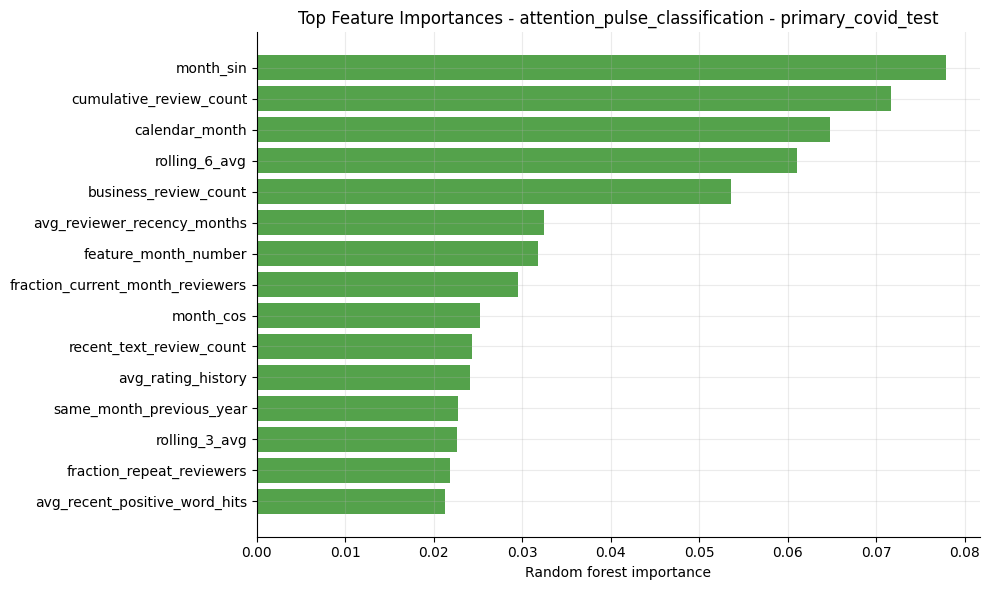

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_feature_importance_primary_covid_test.png


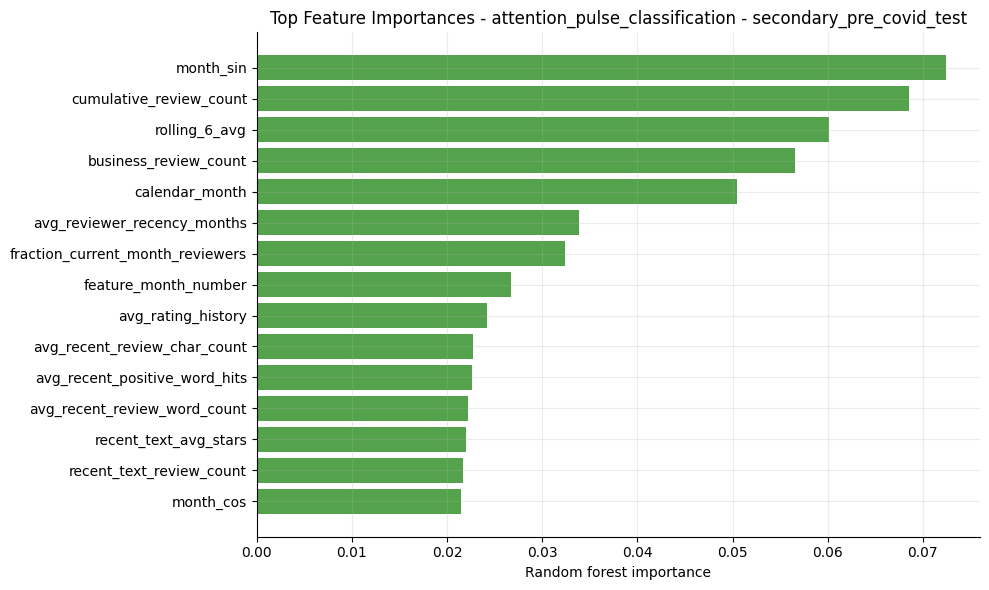

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_feature_importance_secondary_pre_covid_test.png


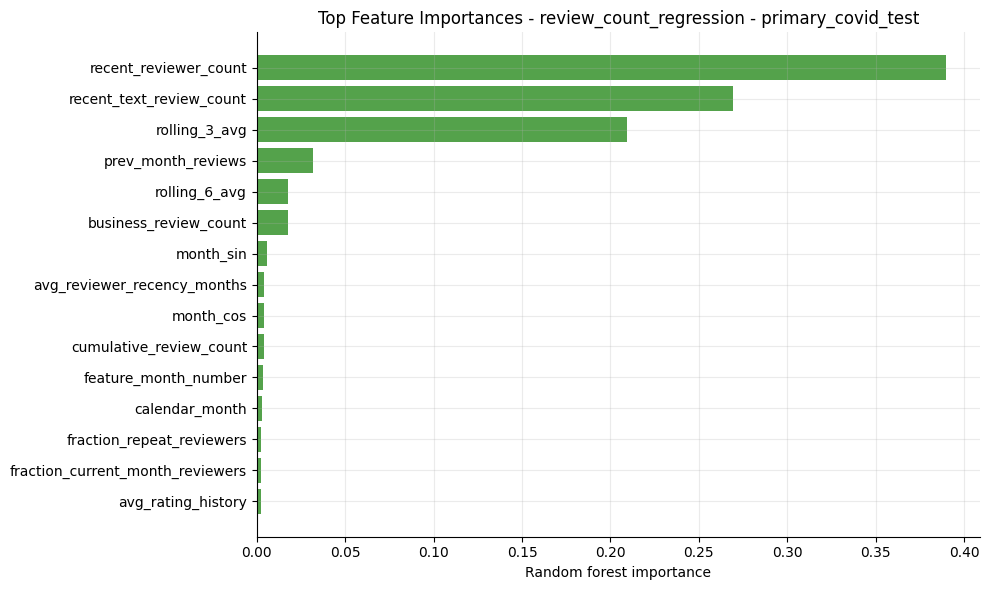

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_feature_importance_primary_covid_test.png


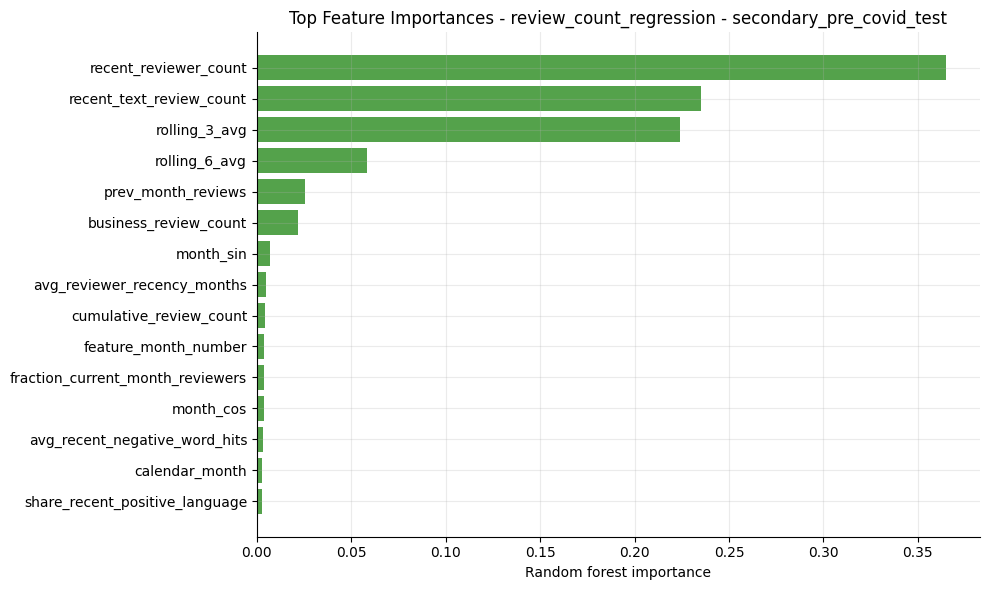

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_feature_importance_secondary_pre_covid_test.png


,task,split,feature,importance
101,attention_pulse_classification,primary_covid_test,month_sin,0.077819
98,attention_pulse_classification,primary_covid_test,cumulative_review_count,0.071684
100,attention_pulse_classification,primary_covid_test,calendar_month,0.064770
96,attention_pulse_classification,primary_covid_test,rolling_6_avg,0.061053
105,attention_pulse_classification,primary_covid_test,business_review_count,0.053565
131,attention_pulse_classification,primary_covid_test,avg_reviewer_recency_months,0.032468
103,attention_pulse_classification,primary_covid_test,feature_month_number,0.031758
132,attention_pulse_classification,primary_covid_test,fraction_current_month_reviewers,0.029525
102,attention_pulse_classification,primary_covid_test,month_cos,0.025229
133,attention_pulse_classification,primary_covid_test,recent_text_review_count,0.024283


In [7]:
importance_rows = []
for (split_name, model_name), (model, features) in regression_models.items():
    if model_name != "ML: all modalities":
        continue
    for feature, importance in zip(features, model.feature_importances_):
        importance_rows.append({"task": "review_count_regression", "split": split_name, "feature": feature, "importance": importance})
for (split_name, model_name), (model, features) in pulse_models.items():
    if model_name != "ML: all modalities":
        continue
    for feature, importance in zip(features, model.feature_importances_):
        importance_rows.append({"task": "attention_pulse_classification", "split": split_name, "feature": feature, "importance": importance})

importance_df = pd.DataFrame(importance_rows).sort_values(["task", "split", "importance"], ascending=[True, True, False])

for (task, split_name), group in importance_df.groupby(["task", "split"]):
    top_importance = group.head(15).sort_values("importance")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_importance["feature"], top_importance["importance"], color="#54A24B")
    ax.set_title(f"Top Feature Importances - {task} - {split_name}")
    ax.set_xlabel("Random forest importance")
    fig.tight_layout()
    safe_task = task.replace("_classification", "").replace("_regression", "")
    path = FIGURES_DIR / f"{safe_task}_feature_importance_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

importance_df.head(20)

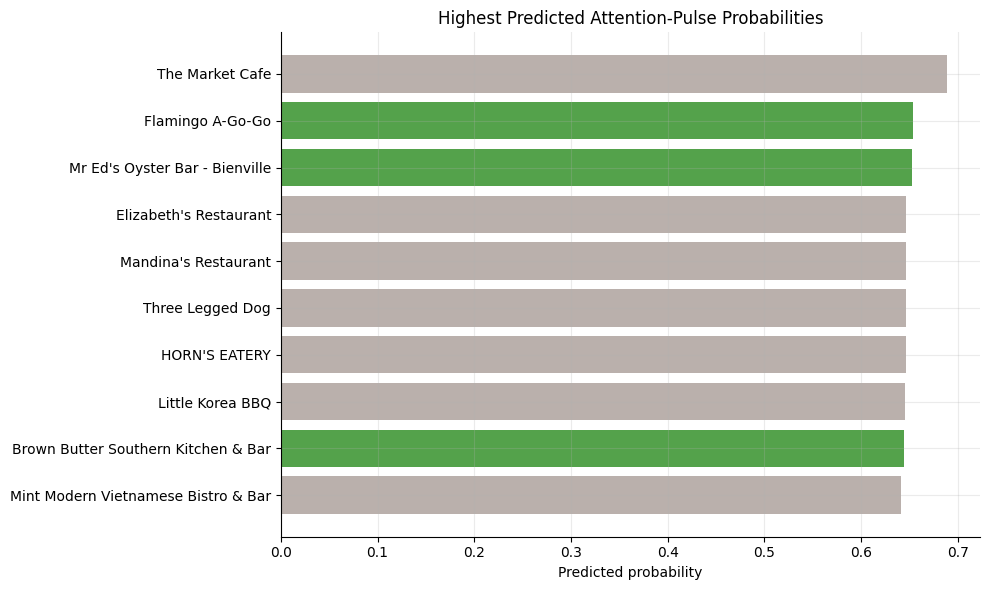

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_top_predicted_examples.png


,business_id,name,target_month_str,attention_pulse,target_next_month_reviews,pulse_baseline_reviews,pulse_relative_lift,probability
0,ZLrqw4KCwKyBlVqycUfNbg,The Market Cafe,2020-03,0,3.0,3.666667,0.818182,0.688610
1,YvrV_Tc9syF2Wch0HOIT3A,Flamingo A-Go-Go,2021-03,1,14.0,5.666667,2.470588,0.653468
2,EME5hqQLjBD7e2cLryupbA,Mr Ed's Oyster Bar - Bienville,2021-03,1,18.0,5.000000,3.600000,0.652482
3,IZZ_uR2ps5KuuyE0n--jVA,Elizabeth's Restaurant,2021-03,0,4.0,2.500000,1.600000,0.646795
4,OSi2ColCxhS9oCoAUNbPig,Mandina's Restaurant,2020-03,0,5.0,3.833333,1.304348,0.646472
5,zvGNZF827KyzLupKiG4Xtw,Three Legged Dog,2020-03,0,4.0,3.166667,1.263158,0.646389
6,Bt7NBqA31uOI4H_hvasLLg,HORN'S EATERY,2020-03,0,0.0,5.500000,0.000000,0.646374
7,-psZLTe6IJTQUB-bZF7Zyg,Little Korea BBQ,2020-03,0,3.0,3.333333,0.900000,0.645386
8,6RDGvdukSq3YHPYvG8sIEQ,Brown Butter Southern Kitchen & Bar,2021-03,1,4.0,1.833333,2.181818,0.644774
9,Vnob_w_Aohf7ZDqxcJ9z2A,Mint Modern Vietnamese Bistro & Bar,2020-03,0,2.0,3.333333,0.600000,0.641669


In [8]:
example_split = "primary_covid_test"
example_model = "ML: all modalities"
examples = (
    pulse_predictions_df[(pulse_predictions_df["split"] == example_split) & (pulse_predictions_df["model"] == example_model)]
    .sort_values("probability", ascending=False)
    .head(10)
    .merge(business_lookup, on="business_id", how="left")
)

fig, ax = plt.subplots(figsize=(10, 6))
labels = examples["name"].fillna(examples["business_id"]).str.slice(0, 35)
colors = np.where(examples["attention_pulse"].eq(1), "#54A24B", "#BAB0AC")
ax.barh(labels[::-1], examples["probability"].values[::-1], color=colors[::-1])
ax.set_title("Highest Predicted Attention-Pulse Probabilities")
ax.set_xlabel("Predicted probability")
fig.tight_layout()
path = FIGURES_DIR / "attention_pulse_top_predicted_examples.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path)

examples[["business_id", "name", "target_month_str", "attention_pulse", "target_next_month_reviews", "pulse_baseline_reviews", "pulse_relative_lift", "probability"]]

## Modeling Takeaways

- The corrected modeling cohort contains **876 businesses** and **68,249 business-month rows**, filtered to active businesses in the 2015-2021 modeling window.
- Review-count regression is still dominated by recent temporal activity. In the COVID-era test, the last-month baseline is strongest; in the pre-COVID test, historical + business features perform best.
- Attention-pulse classification is the more distinctive community-attention task, but pulses remain hard to classify. Simple pulse baselines are competitive on F1 during the COVID-era test.
- SNA and NLP features add interpretable context, but their incremental predictive gain is modest compared with historical and business signals.
- Figures are named by task: `review_count_*` for regression and `attention_pulse_*` for classification.